In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from kneed import KneeLocator

import warnings
warnings.filterwarnings('ignore')

# Apply a clean and modern visualization style
sns.set(style="whitegrid", palette="deep")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_excel(r"C:\Users\PC\Downloads\archive\Online Retail.xlsx",
                   engine='openpyxl')

print("Dataset loaded!")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset loaded!
Shape: 541909 rows and 8 columns

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [15]:
print("Column names and data types:")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Basic Stats ---")
print(f"Total customers  : {df['CustomerID'].nunique()}")
print(f"Total products   : {df['StockCode'].nunique()}")
print(f"Total countries  : {df['Country'].nunique()}")
print(f"Date range       : {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Column names and data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

--- Missing Values ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--- Basic Stats ---
Total customers  : 4372
Total products   : 4070
Total countries  : 38
Date range       : 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [16]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [3]:
df = df.dropna(subset=['CustomerID'])
print(f"After removing missing CustomerID: {df.shape[0]} rows")

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After removing cancelled orders : {df.shape[0]} rows")

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"After removing bad quantities   : {df.shape[0]} rows")

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['CustomerID'] = df['CustomerID'].astype(int)

print("\n✅ Cleaning done!")

After removing missing CustomerID: 406829 rows
After removing cancelled orders : 397924 rows
After removing bad quantities   : 397884 rows

✅ Cleaning done!


In [4]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(f"\nRFM table created with {len(rfm)} customers")
print("\nFirst 5 rows:")
rfm.head()

Reference date: 2011-12-10

RFM table created with 4338 customers

First 5 rows:


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [5]:
def remove_outliers(data, columns):
    clean = data.copy()
    for col in columns:
        Q1 = clean[col].quantile(0.25)
        Q3 = clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR
        clean = clean[(clean[col] >= lower) & (clean[col] <= upper)]
    return clean

rfm_clean = remove_outliers(rfm, ['Recency', 'Frequency', 'Monetary'])
print(f"Customers before outlier removal: {len(rfm)}")
print(f"Customers after  outlier removal: {len(rfm_clean)}")
print(f"Removed {len(rfm) - len(rfm_clean)} outliers")

scaler = StandardScaler()
X = scaler.fit_transform(rfm_clean[['Recency', 'Frequency', 'Monetary']])

print("\n✅ Data scaled using StandardScaler")
print("Scaled data shape:", X.shape)

Customers before outlier removal: 4338
Customers after  outlier removal: 4057
Removed 281 outliers

✅ Data scaled using StandardScaler
Scaled data shape: (4057, 3)


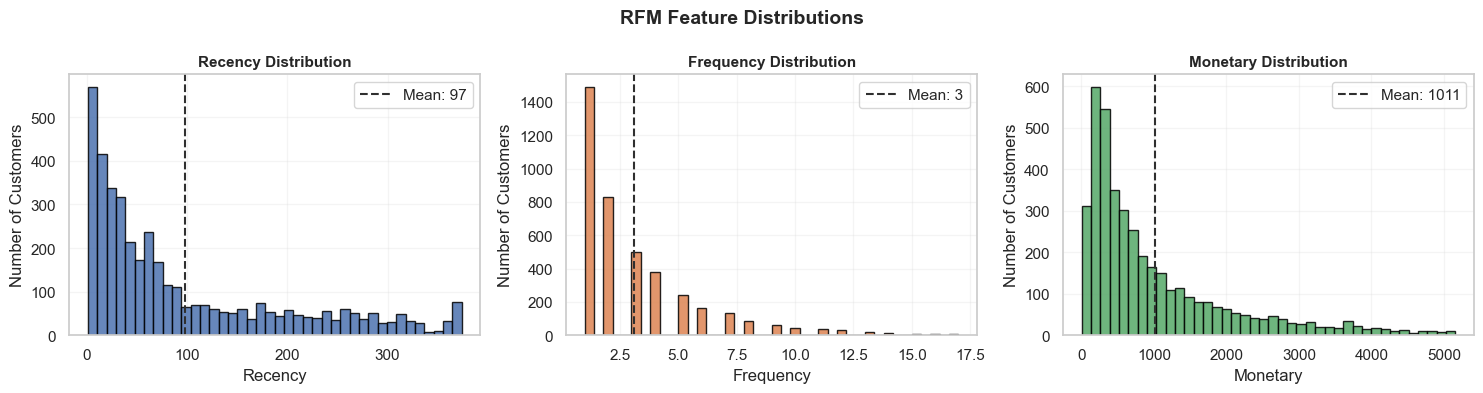

💡 Observation: Most customers show high recency with relatively low purchase frequency, indicating many inactive or one-time buyers.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868']
features = ['Recency', 'Frequency', 'Monetary']

for i, (col, color) in enumerate(zip(features, colors)):
    axes[i].hist(rfm_clean[col], bins=40, color=color, alpha=0.85, edgecolor='black')
    axes[i].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Customers')
    axes[i].axvline(rfm_clean[col].mean(), color='#2F2F2F', linestyle='--',
                    linewidth=1.5,
                    label=f'Mean: {rfm_clean[col].mean():.0f}')
    axes[i].legend()
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print("💡 Observation: Most customers show high recency with relatively low purchase frequency, indicating many inactive or one-time buyers.")

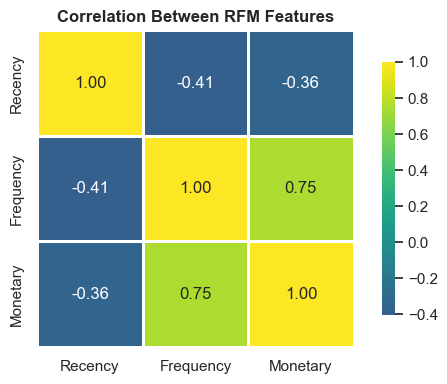

💡 Weak correlations suggest each feature captures a different aspect of customer behavior, making them valuable for clustering.


In [7]:
plt.figure(figsize=(6, 4))
corr = rfm_clean[features].corr()

sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='viridis', center=0,
            linewidths=1, square=True,
            annot_kws={'size': 12},
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Between RFM Features', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

print("💡 Weak correlations suggest each feature captures a different aspect of customer behavior, making them valuable for clustering.")

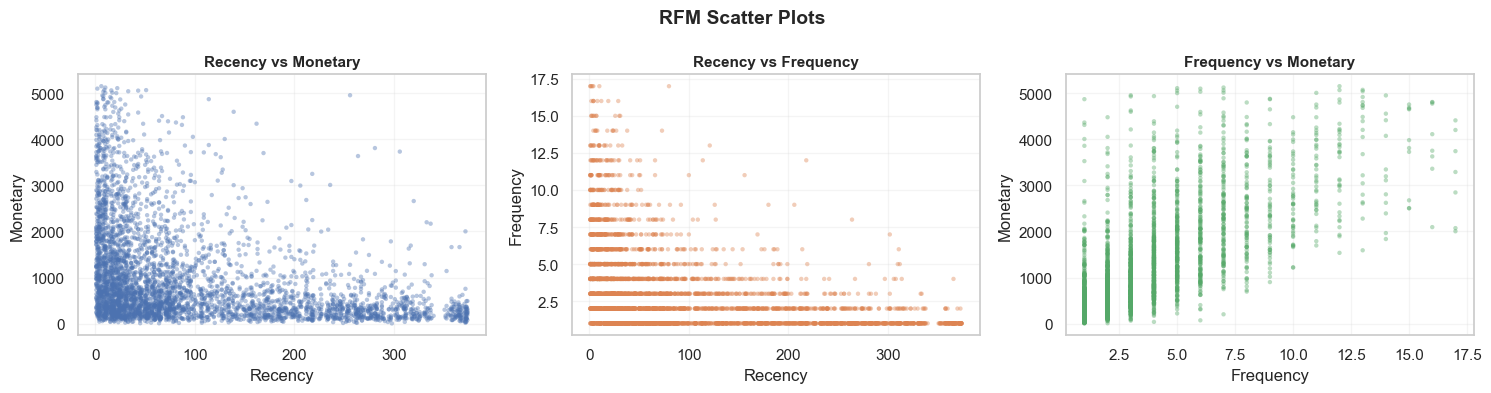

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RFM Scatter Plots', fontsize=14, fontweight='bold')

pairs = [('Recency', 'Monetary'), ('Recency', 'Frequency'), ('Frequency', 'Monetary')]
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, ((x_col, y_col), color) in enumerate(zip(pairs, colors)):
    axes[i].scatter(rfm_clean[x_col], rfm_clean[y_col],
                    alpha=0.4, s=10, color=color, edgecolors='none')
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].set_title(f'{x_col} vs {y_col}', fontsize=11, fontweight='bold')
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

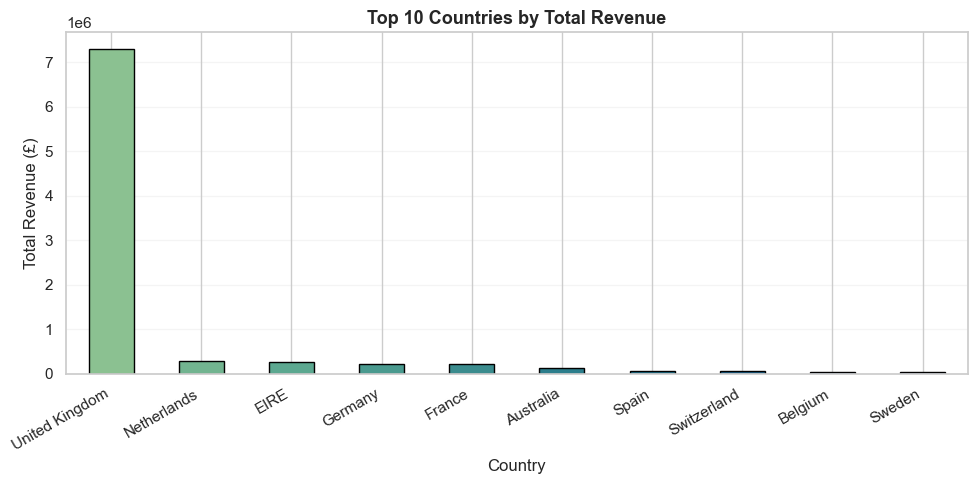

In [9]:
top10 = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
colors = sns.color_palette("crest", len(top10))

top10.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Top 10 Countries by Total Revenue', fontweight='bold', fontsize=13)
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=30, ha='right')

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('eda_countries.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
k_values = range(2, 11)
inertias = []
silhouettes = []

print("Testing different values of K...")
print(f"{'K':>3} | {'Inertia':>12} | {'Silhouette':>12}")
print("-" * 35)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

    print(f"{k:>3} | {km.inertia_:>12.1f} | {silhouette_score(X, labels):>12.4f}")

knee = KneeLocator(list(k_values), inertias, curve='convex', direction='decreasing')
BEST_K = knee.knee if knee.knee else 4

print(f"\n✅ Best K detected automatically: K = {BEST_K}")

Testing different values of K...
  K |      Inertia |   Silhouette
-----------------------------------
  2 |       6626.3 |       0.4782
  3 |       3787.3 |       0.4785
  4 |       2870.1 |       0.4455
  5 |       2418.1 |       0.4178
  6 |       2048.8 |       0.3861
  7 |       1761.7 |       0.3789
  8 |       1603.6 |       0.3698
  9 |       1490.8 |       0.3515
 10 |       1391.5 |       0.3516

✅ Best K detected automatically: K = 4


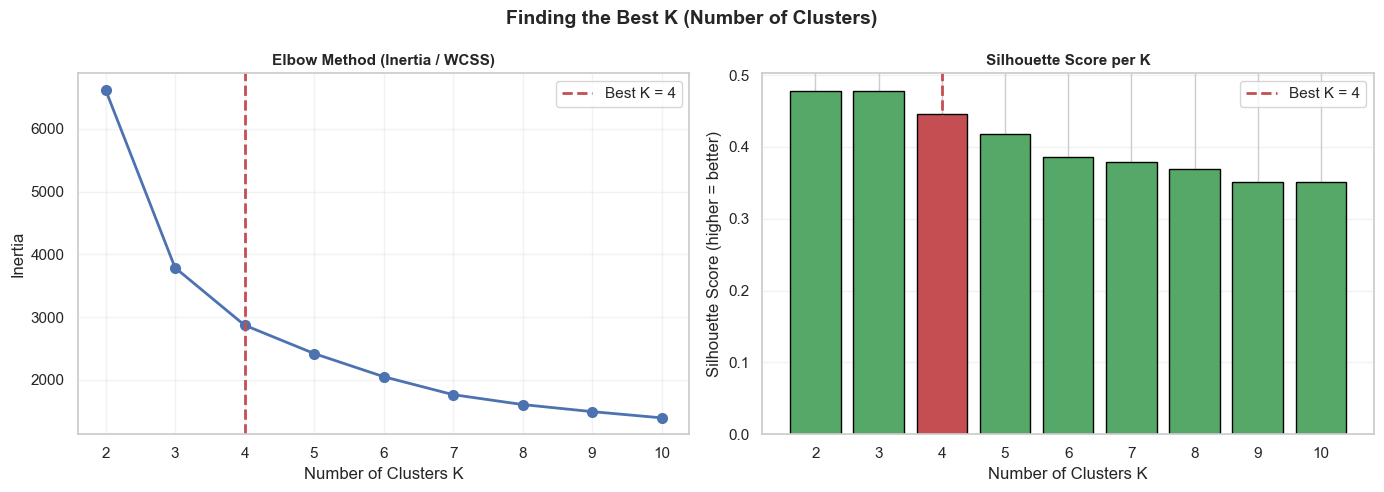


💡 The highlighted line and bars emphasize the optimal number of clusters: K = 4


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding the Best K (Number of Clusters)', fontsize=14, fontweight='bold')

k_list = list(k_values)

# Left: Elbow (Inertia)
axes[0].plot(k_list, inertias, marker='o',
             color='#4C72B0', linewidth=2, markersize=7)
axes[0].axvline(BEST_K, color='#C44E52', linestyle='--', linewidth=2,
                label=f'Best K = {BEST_K}')
axes[0].set_title('Elbow Method (Inertia / WCSS)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[0].set_xticks(k_list)

# Right: Silhouette Score
bar_colors = ['#C44E52' if k == BEST_K else '#55A868' for k in k_list]
axes[1].bar(k_list, silhouettes, color=bar_colors, edgecolor='black')
axes[1].set_title('Silhouette Score per K', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_xticks(k_list)
axes[1].grid(alpha=0.25, axis='y')

axes[1].axvline(BEST_K, color='#C44E52', linestyle='--', linewidth=2,
                label=f'Best K = {BEST_K}')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n💡 The highlighted line and bars emphasize the optimal number of clusters: K = {BEST_K}")

In [12]:
print(f"Training K-Means with K = {BEST_K}...")

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=20,
    max_iter=300
)

cluster_labels = kmeans.fit_predict(X)

rfm_clean = rfm_clean.copy()
rfm_clean['Cluster'] = cluster_labels

print(f"\n✅ K-Means done! Each customer now has a cluster label (0 to {BEST_K-1})")

print("\nCluster sizes:")
for c, count in rfm_clean['Cluster'].value_counts().sort_index().items():
    print(f"  Cluster {c}: {count} customers ({count/len(rfm_clean)*100:.1f}%)")

Training K-Means with K = 4...

✅ K-Means done! Each customer now has a cluster label (0 to 3)

Cluster sizes:
  Cluster 0: 1893 customers (46.7%)
  Cluster 1: 977 customers (24.1%)
  Cluster 2: 349 customers (8.6%)
  Cluster 3: 838 customers (20.7%)


In [13]:
print("\nAverage RFM values for each cluster:")
cluster_summary = rfm_clean.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_summary


Average RFM values for each cluster:


,Recency,Frequency,Monetary
Cluster,,,
0,54.4,1.9,532.5
1,255.6,1.4,393.0
2,25.6,9.6,3390.8
3,40.3,5.0,1820.6


In [14]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

explained = pca.explained_variance_ratio_ * 100
print(f"PCA explains {explained[0]:.1f}% + {explained[1]:.1f}% = {sum(explained):.1f}% of total variance")

PCA explains 67.7% + 24.0% = 91.8% of total variance


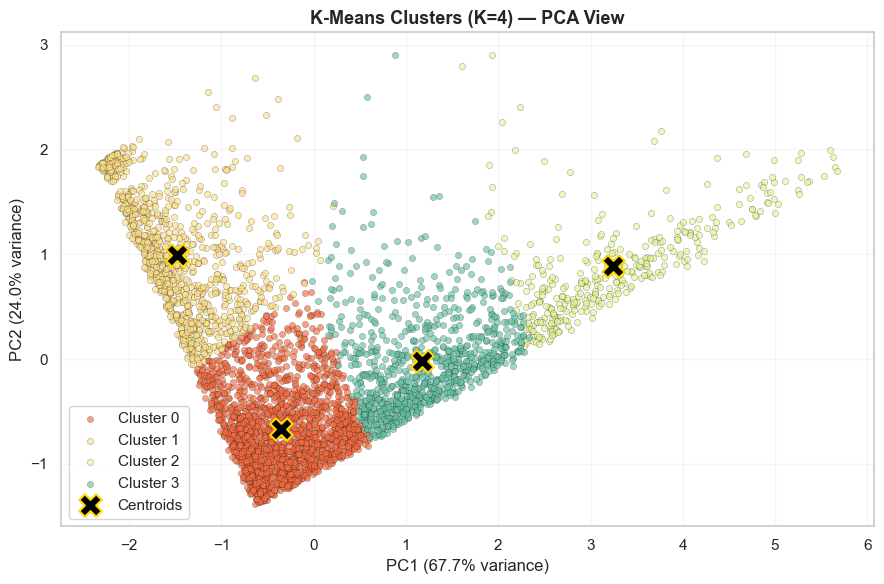

In [16]:
plt.figure(figsize=(9, 6))

colors = sns.color_palette("Spectral", BEST_K)

for c in range(BEST_K):
    mask = cluster_labels == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                color=colors[c], alpha=0.65, s=20,
                edgecolors='black', linewidth=0.2,
                label=f'Cluster {c}')

centers_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
            color='#000000', marker='X', s=260,
            edgecolor='#FFD700', linewidth=1.5,
            zorder=6, label='Centroids')

plt.title(f'K-Means Clusters (K={BEST_K}) — PCA View', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('kmeans_clusters_pca.png', dpi=120, bbox_inches='tight')
plt.show()

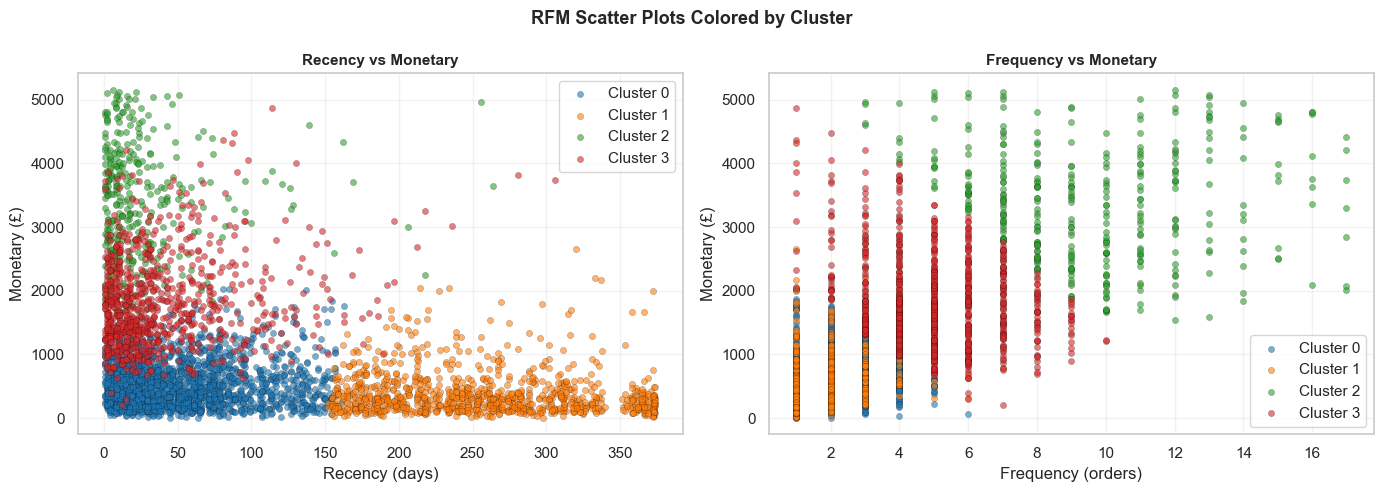

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RFM Scatter Plots Colored by Cluster', fontsize=13, fontweight='bold')

colors = sns.color_palette("tab10", BEST_K)

for c in range(BEST_K):
    mask = cluster_labels == c
    axes[0].scatter(rfm_clean.loc[mask, 'Recency'],
                    rfm_clean.loc[mask, 'Monetary'],
                    color=colors[c], alpha=0.6, s=20,
                    edgecolors='black', linewidth=0.2,
                    label=f'Cluster {c}')
    
    axes[1].scatter(rfm_clean.loc[mask, 'Frequency'],
                    rfm_clean.loc[mask, 'Monetary'],
                    color=colors[c], alpha=0.6, s=20,
                    edgecolors='black', linewidth=0.2,
                    label=f'Cluster {c}')

axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Recency vs Monetary', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary', fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig('kmeans_rfm_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

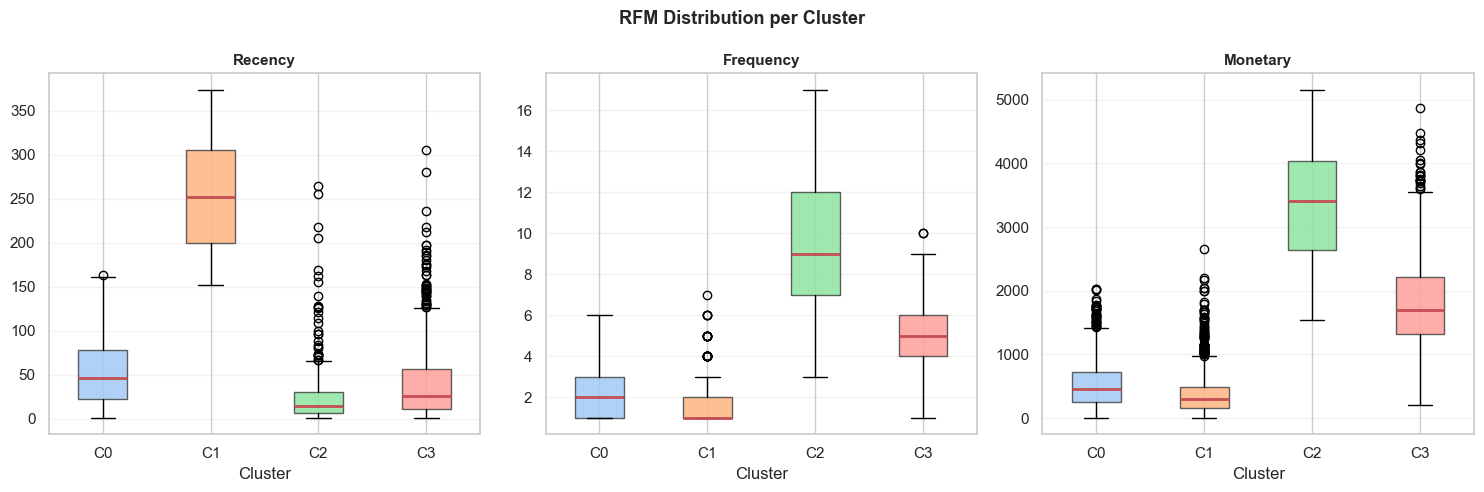

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RFM Distribution per Cluster', fontsize=13, fontweight='bold')

colors = sns.color_palette("pastel", BEST_K)

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    data_per_cluster = [rfm_clean[rfm_clean['Cluster'] == c][col].values
                        for c in range(BEST_K)]
    
    bp = axes[i].boxplot(data_per_cluster,
                         labels=[f'C{c}' for c in range(BEST_K)],
                         patch_artist=True)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor('#444444')
    
    for median in bp['medians']:
        median.set_color('#C44E52')
        median.set_linewidth(2)

    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('kmeans_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

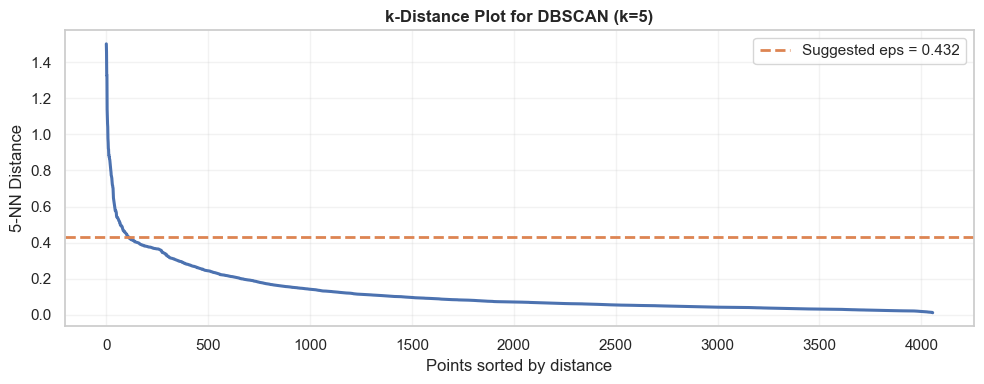


Suggested parameters: eps = 0.432, min_samples = 5


In [20]:
MIN_SAMPLES = 5

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
distances, _ = nbrs.kneighbors(X)

k_dist = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

knee_eps = KneeLocator(range(len(k_dist)), k_dist, curve='convex', direction='decreasing')
best_eps = k_dist[knee_eps.knee] if knee_eps.knee else 0.5

plt.figure(figsize=(10, 4))
plt.plot(k_dist, color='#4C72B0', linewidth=2.2)
plt.axhline(best_eps, color='#DD8452', linestyle='--', linewidth=2,
            label=f'Suggested eps = {best_eps:.3f}')

plt.title(f'k-Distance Plot for DBSCAN (k={MIN_SAMPLES})', fontweight='bold', fontsize=12)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-NN Distance')

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('dbscan_kdist.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nSuggested parameters: eps = {best_eps:.3f}, min_samples = {MIN_SAMPLES}")

In [21]:
dbscan = DBSCAN(eps=best_eps, min_samples=MIN_SAMPLES)
db_labels = dbscan.fit_predict(X)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = np.sum(db_labels == -1)

print(f"DBSCAN Results:")
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")
print()
for lbl in sorted(set(db_labels)):
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    count = np.sum(db_labels == lbl)
    print(f"  {name}: {count} points")

DBSCAN Results:
  Clusters found : 1
  Noise points   : 59 (1.5%)

  Noise: 59 points
  Cluster 0: 3998 points


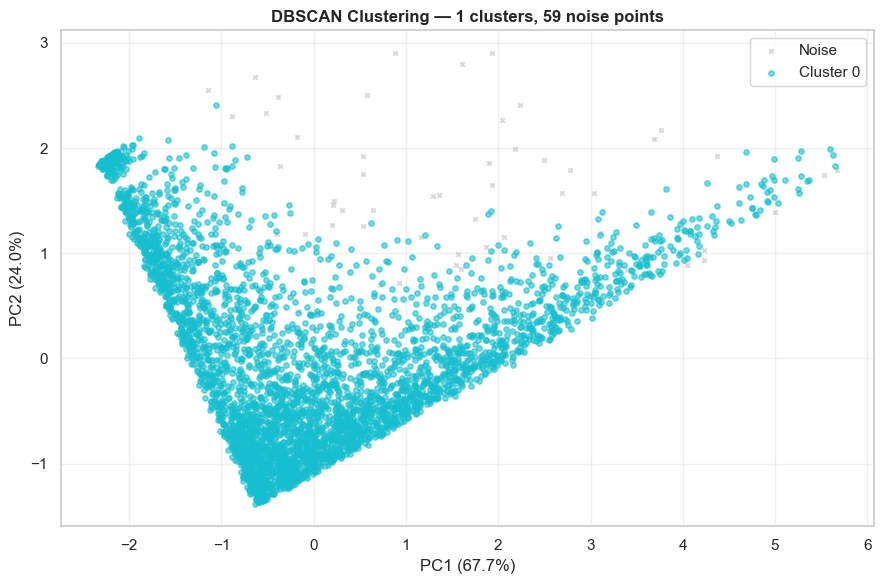

In [22]:
plt.figure(figsize=(9, 6))

unique_labels = sorted(set(db_labels))
db_colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 2)))

for i, lbl in enumerate(unique_labels):
    mask = db_labels == lbl
    if lbl == -1:
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                    color='grey', alpha=0.3, s=10, marker='x', label='Noise')
    else:
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                    color=db_colors[i], alpha=0.6, s=15, label=f'Cluster {lbl}')

plt.title(f'DBSCAN Clustering — {n_clusters} clusters, {n_noise} noise points', fontweight='bold')
plt.xlabel(f'PC1 ({explained[0]:.1f}%)')
plt.ylabel(f'PC2 ({explained[1]:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

In [29]:
from sklearn.metrics import silhouette_samples, davies_bouldin_score, calinski_harabasz_score
import matplotlib.cm as cm

# ─── Calculate all metrics for K-Means ────────────────────────────────────
km_sil = silhouette_score(X, cluster_labels)
km_db  = davies_bouldin_score(X, cluster_labels)
km_ch  = calinski_harabasz_score(X, cluster_labels)

print("=" * 50)
print("K-MEANS PERFORMANCE METRICS")
print("=" * 50)
print(f"  Silhouette Score      : {km_sil:.4f}  (higher is better, max=1)")
print(f"  Davies-Bouldin Score  : {km_db:.4f}   (lower is better)")
print(f"  Calinski-Harabasz     : {km_ch:.2f}  (higher is better)")

# ─── Calculate for DBSCAN (only if we found valid clusters) ───────────────
valid_mask = db_labels != -1
if n_clusters >= 2 and valid_mask.sum() > 0:
    db_sil = silhouette_score(X[valid_mask], db_labels[valid_mask])
    db_db  = davies_bouldin_score(X[valid_mask], db_labels[valid_mask])
    db_ch  = calinski_harabasz_score(X[valid_mask], db_labels[valid_mask])
    print(f"\n{'='*50}")
    print("DBSCAN PERFORMANCE METRICS")
    print(f"{'='*50}")
    print(f"  Silhouette Score      : {db_sil:.4f}")
    print(f"  Davies-Bouldin Score  : {db_db:.4f}")
    print(f"  Calinski-Harabasz     : {db_ch:.2f}")
else:
    db_sil = None
    print("\nDBSCAN: Not enough clusters for full metrics")

K-MEANS PERFORMANCE METRICS
  Silhouette Score      : 0.4455  (higher is better, max=1)
  Davies-Bouldin Score  : 0.8601   (lower is better)
  Calinski-Harabasz     : 4378.04  (higher is better)

DBSCAN: Not enough clusters for full metrics


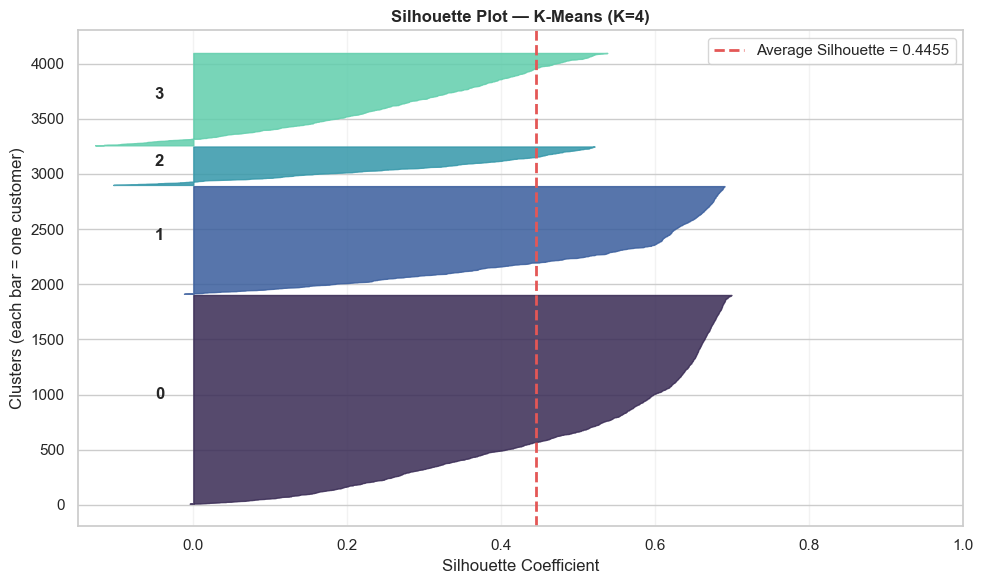


💡 Wider sections indicate stronger cluster separation.
   Values closer to 1 represent well-clustered customers.


In [32]:
sil_vals = silhouette_samples(X, cluster_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

colors = sns.color_palette("mako", BEST_K)

for c in range(BEST_K):
    c_sil_vals = sorted(sil_vals[cluster_labels == c])
    size = len(c_sil_vals)
    y_upper = y_lower + size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil_vals,
                     alpha=0.85, color=colors[c])
    
    ax.text(-0.05, y_lower + size / 2, str(c),
            fontsize=12, fontweight='bold')
    
    y_lower = y_upper + 10

ax.axvline(km_sil, color='#E45756', linestyle='--', linewidth=2,
           label=f'Average Silhouette = {km_sil:.4f}')

ax.set_title(f'Silhouette Plot — K-Means (K={BEST_K})', fontweight='bold', fontsize=12)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Clusters (each bar = one customer)')
ax.set_xlim([-0.15, 1])

ax.legend()
ax.grid(alpha=0.25, axis='x')

plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n💡 Wider sections indicate stronger cluster separation.")
print("   Values closer to 1 represent well-clustered customers.")

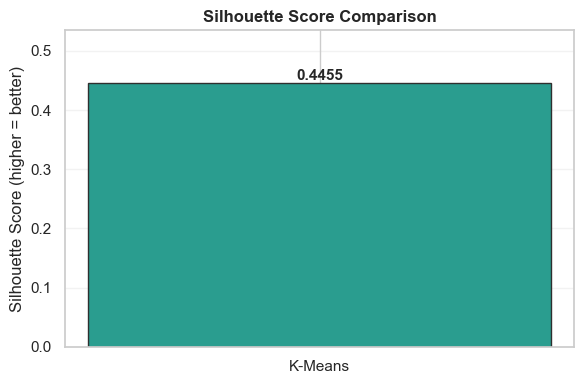

In [33]:
algorithms = ['K-Means']
sil_scores = [km_sil]

if db_sil is not None:
    algorithms.append('DBSCAN')
    sil_scores.append(db_sil)

plt.figure(figsize=(6, 4))

bar_colors = ['#7B8CDE' if s != max(sil_scores) else '#2A9D8F' for s in sil_scores]

bars = plt.bar(algorithms, sil_scores,
               color=bar_colors, edgecolor='#2F2F2F', linewidth=1, width=0.4)

for bar, val in zip(bars, sil_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}',
             ha='center', fontsize=11, fontweight='bold')

plt.title('Silhouette Score Comparison', fontweight='bold', fontsize=12)
plt.ylabel('Silhouette Score (higher = better)')
plt.ylim(0, max(sil_scores) * 1.2)

plt.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [34]:
cluster_profile = rfm_clean.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profile['Size'] = rfm_clean['Cluster'].value_counts().sort_index()

print("Cluster Profiles (average values):")
print(cluster_profile.to_string())
print()
print("Interpretation guide:")
print("  Recency  : Lower = bought more recently (BETTER)")
print("  Frequency: Higher = bought more often   (BETTER)")
print("  Monetary : Higher = spent more money    (BETTER)")

Cluster Profiles (average values):
         Recency  Frequency  Monetary  Size
Cluster                                    
0           54.4        1.9     532.5  1893
1          255.6        1.4     393.0   977
2           25.6        9.6    3390.8   349
3           40.3        5.0    1820.6   838

Interpretation guide:
  Recency  : Lower = bought more recently (BETTER)
  Frequency: Higher = bought more often   (BETTER)
  Monetary : Higher = spent more money    (BETTER)


In [35]:
rec_rank  = cluster_profile['Recency'].rank()
freq_rank = cluster_profile['Frequency'].rank(ascending=False)
mon_rank  = cluster_profile['Monetary'].rank(ascending=False)
combined  = (rec_rank + freq_rank + mon_rank) / 3

ranked_clusters = combined.sort_values().index.tolist()

segment_names = [
    '🏆 Champions',
    '⚡ Loyal Customers',
    '🌱 New/Promising',
    '⚠️ At Risk',
    '💤 Hibernating',
    '👋 Lost'
]

segment_map = {cluster: segment_names[i] for i, cluster in enumerate(ranked_clusters)
               if i < len(segment_names)}

rfm_clean['Segment'] = rfm_clean['Cluster'].map(segment_map)

print("Cluster → Segment Assignment:")
print("-" * 55)

for c in sorted(segment_map.keys()):
    row = cluster_profile.loc[c]
    n = int(row['Size'])
    print(f"  Cluster {c} → {segment_map[c]}")
    print(f"    Customers: {n:,} | Recency: {row['Recency']:.0f}d | "
          f"Frequency: {row['Frequency']:.1f} | Monetary: £{row['Monetary']:,.0f}")
    print()

Cluster → Segment Assignment:
-------------------------------------------------------
  Cluster 0 → 🌱 New/Promising
    Customers: 1,893 | Recency: 54d | Frequency: 1.9 | Monetary: £532

  Cluster 1 → ⚠️ At Risk
    Customers: 977 | Recency: 256d | Frequency: 1.4 | Monetary: £393

  Cluster 2 → 🏆 Champions
    Customers: 349 | Recency: 26d | Frequency: 9.6 | Monetary: £3,391

  Cluster 3 → ⚡ Loyal Customers
    Customers: 838 | Recency: 40d | Frequency: 5.0 | Monetary: £1,821



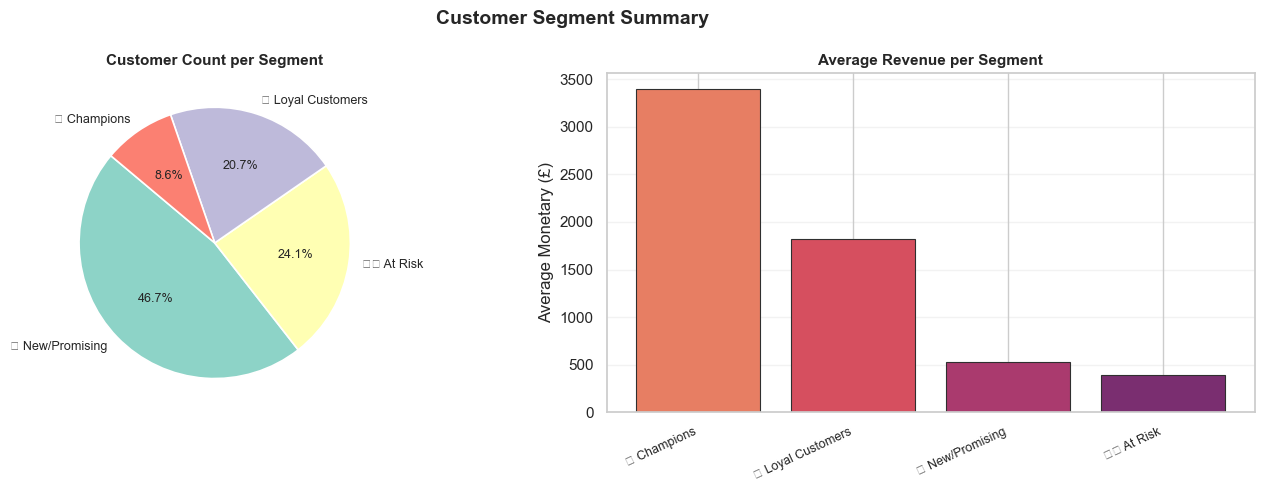

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Segment Summary', fontsize=14, fontweight='bold')

seg_counts = rfm_clean['Segment'].value_counts()
seg_colors = sns.color_palette("Set3", len(seg_counts))

axes[0].pie(seg_counts.values,
            labels=seg_counts.index,
            autopct='%1.1f%%',
            colors=seg_colors,
            startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.2),
            textprops={'fontsize': 9})
axes[0].set_title('Customer Count per Segment', fontsize=11, fontweight='bold')

seg_monetary = rfm_clean.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
seg_bar_colors = sns.color_palette("flare", len(seg_monetary))

bars = axes[1].bar(range(len(seg_monetary)),
                   seg_monetary.values,
                   color=seg_bar_colors,
                   edgecolor='#2F2F2F',
                   linewidth=0.8)

axes[1].set_xticks(range(len(seg_monetary)))
axes[1].set_xticklabels(seg_monetary.index, rotation=25, ha='right', fontsize=9)
axes[1].set_title('Average Revenue per Segment', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Average Monetary (£)')
axes[1].grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('segment_summary.png', dpi=120, bbox_inches='tight')
plt.show()

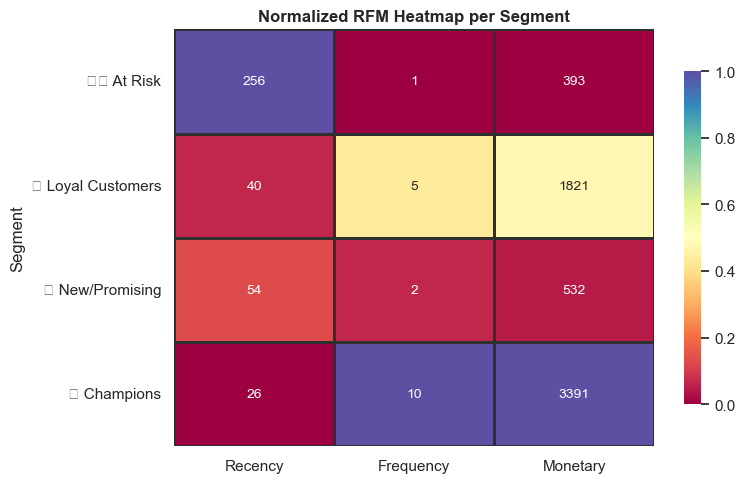

💡 Lower Recency indicates recent activity, while higher Frequency and Monetary reflect stronger customer value.


In [37]:
seg_rfm = rfm_clean.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()
seg_rfm_norm = (seg_rfm - seg_rfm.min()) / (seg_rfm.max() - seg_rfm.min() + 1e-9)

plt.figure(figsize=(8, 5))

sns.heatmap(seg_rfm_norm,
            annot=seg_rfm.round(0),
            fmt='g',
            cmap='Spectral',
            linewidths=0.8,
            linecolor='#2F2F2F',
            annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8})

plt.title('Normalized RFM Heatmap per Segment', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('rfm_heatmap_segments.png', dpi=120, bbox_inches='tight')
plt.show()

print("💡 Lower Recency indicates recent activity, while higher Frequency and Monetary reflect stronger customer value.")

In [48]:
# --- Final: Business Recommendations ---
print("""
╔═══════════════════════════════════════════════════════
║              WHAT TO DO WITH EACH SEGMENT?                   
╠═══════════════════════════════════════════════════════
║                                                              
║  🏆 CHAMPIONS                                               
║     Bought recently, buy often, spend the most.              
║     → Reward them! Give early access to new products.       
║     → Ask them to write reviews or refer friends.            
║                                                              
║  ⚡ LOYAL CUSTOMERS                                          
║     Buy regularly. Spend a good amount.                      
║     → Offer loyalty points or membership perks.              
║     → Suggest premium products (upselling).                  
║                                                              
║  🌱 NEW / PROMISING                                          
║     Bought recently but not very often yet.                  
║     → Send welcome emails and helpful guides.                
║     → Offer a discount on their second purchase.             
║                                                              
║  ⚠️  AT RISK                                                 
║     Used to buy regularly, but haven't recently.            
║     → Send a 'We miss you!' email with a discount.           
║     → Show them what's new since their last visit.           
║                                                              
║  💤 HIBERNATING                                              
║     Haven't bought in a long time. Low activity.            
║     → Send a re-engagement campaign.                         
║     → Ask for feedback on why they stopped buying.           
║                                                              
║  👋 LOST                                                     
║     Last purchase was very long ago. Low value.              
║     → Make one last effort with a big offer.                 
║     → If no response, focus budget on other segments.        
║                                                              
╚═══════════════════════════════════════════════════════
""")


╔═══════════════════════════════════════════════════════
║              WHAT TO DO WITH EACH SEGMENT?                   
╠═══════════════════════════════════════════════════════
║                                                              
║  🏆 CHAMPIONS                                               
║     Bought recently, buy often, spend the most.              
║     → Reward them! Give early access to new products.       
║     → Ask them to write reviews or refer friends.            
║                                                              
║  ⚡ LOYAL CUSTOMERS                                          
║     Buy regularly. Spend a good amount.                      
║     → Offer loyalty points or membership perks.              
║     → Suggest premium products (upselling).                  
║                                                              
║  🌱 NEW / PROMISING                                          
║     Bought recently but not very often yet.             

In [38]:
output = rfm_clean[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].copy()
output.to_csv('customer_segments.csv', index=False)

print("✅ Results saved to: customer_segments.csv")
print(f"   Total customers: {len(output):,}")
print()
print("=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"  Dataset size          : {df.shape[0]:,} transactions")
print(f"  Customers analyzed    : {len(output):,}")
print(f"  Best K (Elbow Method) : {BEST_K}")
print(f"  K-Means Silhouette    : {km_sil:.4f}")
if db_sil:
    print(f"  DBSCAN  Silhouette    : {db_sil:.4f}")
    print(f"  DBSCAN clusters found : {n_clusters}")
print("=" * 55)
print()
print("Segment distribution:")
for seg, cnt in rfm_clean['Segment'].value_counts().items():
    pct = cnt/len(rfm_clean)*100
    print(f"  {seg:<25}: {cnt:>5,} customers ({pct:.1f}%)")

✅ Results saved to: customer_segments.csv
   Total customers: 4,057

FINAL SUMMARY
  Dataset size          : 397,884 transactions
  Customers analyzed    : 4,057
  Best K (Elbow Method) : 4
  K-Means Silhouette    : 0.4455

Segment distribution:
  🌱 New/Promising          : 1,893 customers (46.7%)
  ⚠️ At Risk               :   977 customers (24.1%)
  ⚡ Loyal Customers        :   838 customers (20.7%)
  🏆 Champions              :   349 customers (8.6%)
